**ASSIGNMENT 1 - GROUP 1** 

Christoffer Engskov Frost (s224790)

Michelle Quynh Ngoc Mai (s224771)

Lorenzo Gelao (s253003)

# Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

Draws from: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

* Using your combined dataset (2003–present), plot the total number of incidents per year for each of your Personal Focus Crimes. Display at least the years 2003–2025.
* Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
* Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

/var/folders/xc/9wtnldyd2rlc_nnrrrzqqqn40000gn/T/ipykernel_84883/3468193495.py:5: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_combined = pd.read_csv('Police_Department_Incident_Reports_Historical_Combined.csv')


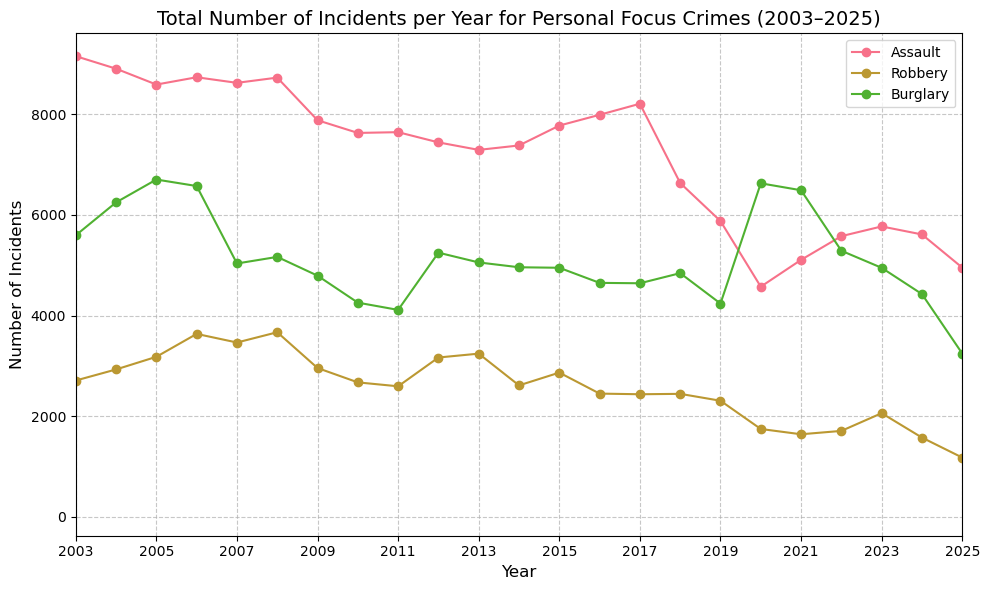

In [183]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the pre-cleaned, combined dataset from Week 2
df_combined = pd.read_csv('Police_Department_Incident_Reports_Historical_Combined.csv')

# 2. Ensure the Date column is a datetime object and extract the Year
df_combined['Date'] = pd.to_datetime(df_combined['Date'], errors='coerce')
df_combined['Year'] = df_combined['Date'].dt.year

# 3. Standardize the 'Unified Category' strings (this was done in your Week 2 script)
df_combined['Unified Category'] = (
    df_combined['Unified Category']
    .astype(str)
    .str.strip()
    .str.title()
)

# 4. Filter for your 3 Personal Focus Crimes
personal_focus_crimes = ['Assault', 'Robbery', 'Burglary']
df_filtered = df_combined[
    df_combined['Unified Category'].isin(personal_focus_crimes)
].copy()

# 5. Plot the total number of incidents per year for each focus crime
plt.figure(figsize=(10, 6))

for crime in personal_focus_crimes:
    crime_data = df_filtered[df_filtered['Unified Category'] == crime]
    crime_incidents_per_year = crime_data.groupby('Year').size()
    
    plt.plot(
        crime_incidents_per_year.index,
        crime_incidents_per_year.values,
        marker='o',
        label=crime
    )

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Total Number of Incidents per Year for Personal Focus Crimes (2003–2025)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(2003, 2025)
plt.xticks(range(2003, 2026, 2))

plt.tight_layout()
plt.show()


# Observations
To examine long-term trends, I plotted the total number of incidents per year from 2003 to 2025 for assault, robbery, and burglary using the combined dataset. The plot shows several clear patterns over the 20+ year period.

One notable feature is the overall downward trend in robbery. Robbery incidents were relatively high in the mid 2000s but gradually declined over time, with a particularly sharp drop after 2019. This decrease may reflect improved policing strategies, changes in economic conditions, or broader national crime trends. The decline around 2020 could also be related to COVID 19, as lockdowns reduced public activity and therefore opportunities for street robbery.

A second clear feature is the sharp drop in assault in 2020, followed by a partial rebound in 2021–2023. The decline in 2020 likely reflects the impact of the COVID 19 pandemic, when stay at home orders reduced social interaction, nightlife activity, and large gatherings. As restrictions eased, assault levels increased again, though they did not immediately return to pre-2020 levels.

Burglary shows more fluctuation over time. It decreases gradually from the mid 2000s but spikes noticeably around 2020–2021 before declining again. This temporary increase could be related to changes in routine activities during the pandemic, such as shifts in residential occupancy patterns or economic stress.

Overall, the plot suggests that while all three crimes show long-term variation, robbery exhibits the clearest long-term decline, and 2020 stands out as a structural break likely influenced by COVID 19. The visualization highlights how external societal factors can significantly impact crime patterns over time.

# Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

**Draws from: Week 3, Exercises 2.1 and 2.2.**

- For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate

$$\gamma(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$

A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.

- Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)

- Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

personal_focus_crimes = ['assault', 'robbery', 'burglary']


df_spatial = df_combined.copy()


df_spatial['Unified Category'] = (
    df_spatial['Unified Category'].astype(str).str.strip().str.lower()
)
df_spatial['Police District'] = (
    df_spatial['Police District'].astype(str).str.strip().str.upper()
)

df_spatial = df_spatial.dropna(subset=['Unified Category', 'Police District', 'Date'])

# df_spatial = df_spatial.dropna(subset=['Incident Date'])
df_spatial['Year'] = df_spatial['Date'].dt.year
df_spatial = df_spatial[(df_spatial['Year'] >= 2003) & (df_spatial['Year'] <= 2025)]

print("Rows used for 1.2:", df_spatial.shape[0])
print("Districts:", df_spatial['Police District'].nunique())

Rows used for 1.2: 2332818
Districts: 12


**Compute the conditional crime profile γ(crime, district)**
 We need:
- \(P(\text{crime})\): citywide baseline probability (computed over **all incidents**)
- \(P(\text{crime}\mid \text{district})\): within-district probability (crime share in that district)
- Then compute the ratio \(\gamma\)

In [185]:
P_crime = df_spatial['Unified Category'].value_counts(normalize=True)

print("Citywide baseline probabilities P(crime):")
for c in personal_focus_crimes:
    print(f"  {c:10s}: {P_crime.get(c, np.nan):.6f}")

P_crime_given_dist = pd.crosstab(
    df_spatial['Police District'],
    df_spatial['Unified Category'],
    normalize='index'
)

P_focus_given_dist = P_crime_given_dist.reindex(columns=personal_focus_crimes, fill_value=0.0)

gamma = P_focus_given_dist.copy()
for c in personal_focus_crimes:
    gamma[c] = gamma[c] / P_crime.get(c, np.nan)

gamma = gamma.sort_index()

print("\nGamma matrix preview:")
display(gamma.head())

Citywide baseline probabilities P(crime):
  assault   : 0.071204
  robbery   : 0.025413
  burglary  : 0.050637

Gamma matrix preview:


Unified Category,assault,robbery,burglary
Police District,,,
BAYVIEW,1.209406,1.164940,1.057839
CENTRAL,0.834629,0.873343,1.025341
INGLESIDE,1.120480,1.358872,1.114524
MISSION,1.204641,1.249736,0.878343
NAN,0.000000,0.000000,0.000000


**Visualize γ ratios clearly (districts × crime types)**
We use a heatmap because it makes it easy to compare:
- across **districts** (rows)
- across **crime types** (columns)
with a natural baseline at **γ = 1**.

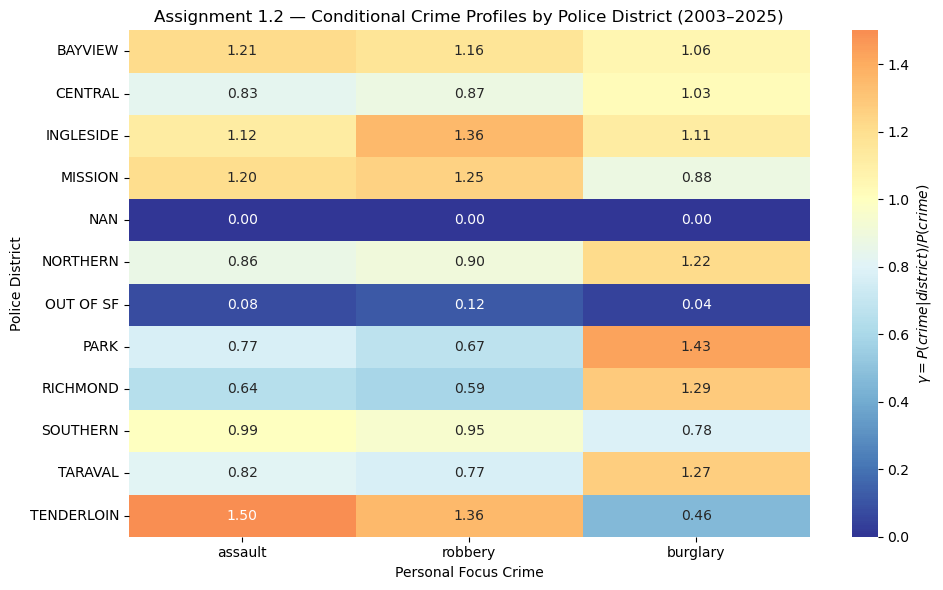

In [186]:
plt.figure(figsize=(10, max(6, 0.35 * len(gamma))))

sns.heatmap(
    gamma,
    annot=True,
    fmt=".2f",
    center=1.0,
    cmap="RdYlBu_r",
    cbar_kws={"label": r"$\gamma = P(crime|district)/P(crime)$"}
)

plt.title("Assignment 1.2 — Conditional Crime Profiles by Police District (2003–2025)")
plt.xlabel("Personal Focus Crime")
plt.ylabel("Police District")
plt.tight_layout()
plt.show()

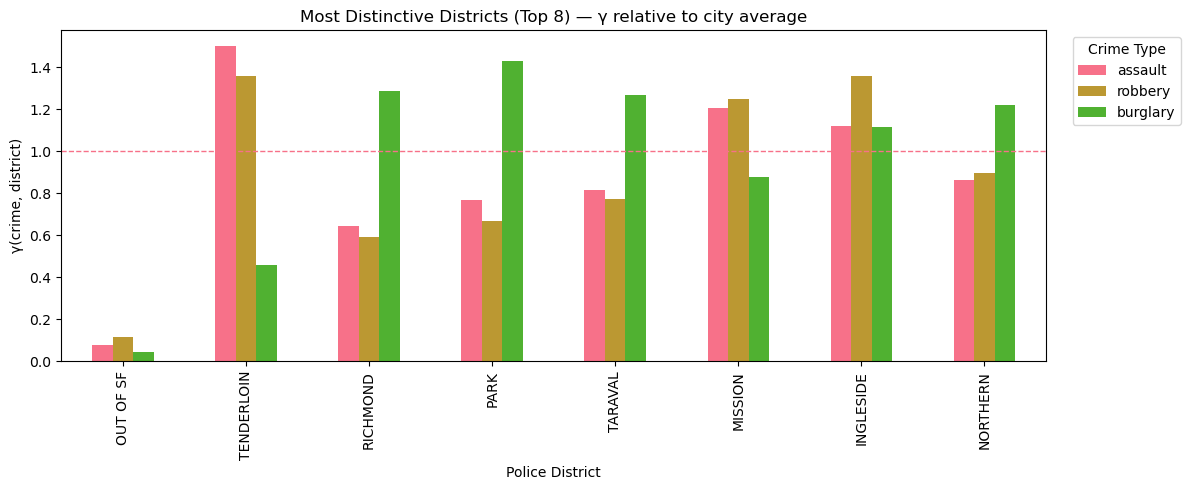

In [187]:
eps = 1e-12
gamma_no_zero = gamma.replace(0, np.nan)

distinctiveness = np.abs(np.log(gamma_no_zero + eps)).mean(axis=1)

top8 = distinctiveness.sort_values(ascending=False).head(8).index

gamma_top8 = gamma.loc[top8]

gamma_top8.plot(kind="bar", figsize=(12, 5))
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Most Distinctive Districts (Top 8) — γ relative to city average")
plt.xlabel("Police District")
plt.ylabel("γ(crime, district)")
plt.legend(title="Crime Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Pick one standout district + describe and explain**

We choose the district with the highest *distinctiveness* score:
mean absolute log-deviation from γ=1 across the three focus crimes.

Then we print its γ values and visualize them against the baseline (γ=1).


Standout district: OUT OF SF

γ values for standout district:


,gamma
Unified Category,
robbery,0.115236
assault,0.079516
burglary,0.042412


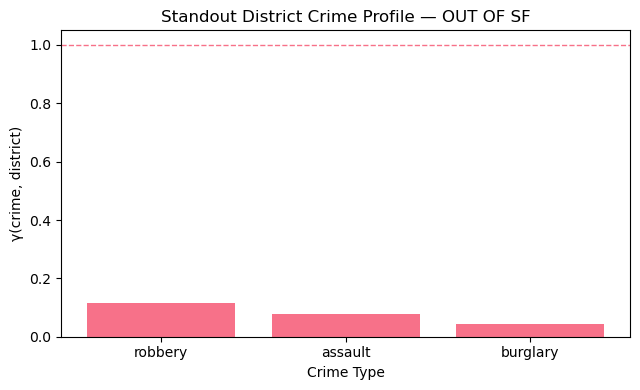

In [188]:
standout_district = distinctiveness.idxmax()
standout_vals = gamma.loc[standout_district].sort_values(ascending=False)

print("Standout district:", standout_district)
print("\nγ values for standout district:")
display(standout_vals.to_frame(name="gamma"))

# Bar plot for standout district
plt.figure(figsize=(6.5, 4))
plt.bar(standout_vals.index, standout_vals.values)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title(f"Standout District Crime Profile — {standout_district}")
plt.xlabel("Crime Type")
plt.ylabel("γ(crime, district)")
plt.tight_layout()
plt.show()

=== ANALYSIS OF ACTUAL SAN FRANCISCO DISTRICTS ===

Most distinctive SF district: TENDERLOIN
Distinctiveness score: 0.497

Crime profile for TENDERLOIN:


,γ value
Unified Category,
assault,1.499989
robbery,1.356811
burglary,0.457600


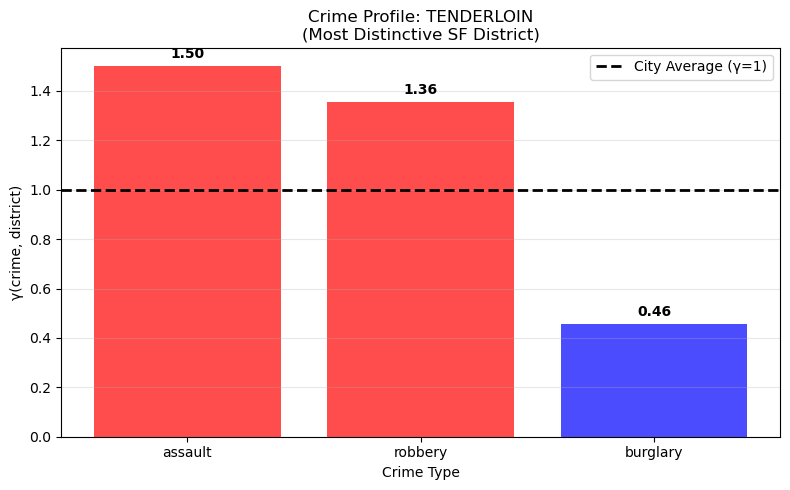


=== INTERPRETATION OF TENDERLOIN ===
• Assault: OVER-represented by 50% (γ=1.50)
• Robbery: OVER-represented by 36% (γ=1.36)
• Burglary: UNDER-represented by 54% (γ=0.46)

This district shows the most extreme deviation from city-wide crime patterns,
making it an excellent example of how geography influences crime distribution.


In [189]:

print("=== ANALYSIS OF ACTUAL SAN FRANCISCO DISTRICTS ===\n")

sf_gamma = gamma.drop('OUT OF SF', errors='ignore')
sf_distinctiveness = distinctiveness.drop('OUT OF SF', errors='ignore')

sf_standout = sf_distinctiveness.idxmax()
print(f"Most distinctive SF district: {sf_standout}")
print(f"Distinctiveness score: {sf_distinctiveness[sf_standout]:.3f}")

print(f"\nCrime profile for {sf_standout}:")
sf_standout_profile = sf_gamma.loc[sf_standout]
display(sf_standout_profile.to_frame(name="γ value"))

plt.figure(figsize=(8, 5))
colors = ['red' if x > 1 else 'blue' for x in sf_standout_profile.values]
bars = plt.bar(sf_standout_profile.index, sf_standout_profile.values, color=colors, alpha=0.7)

plt.axhline(1.0, linestyle="--", linewidth=2, color='black', label='City Average (γ=1)')
plt.title(f"Crime Profile: {sf_standout}\n(Most Distinctive SF District)")
plt.xlabel("Crime Type")
plt.ylabel("γ(crime, district)")
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, sf_standout_profile.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{value:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n=== INTERPRETATION OF {sf_standout} ===")
for crime, gamma_val in sf_standout_profile.items():
    if gamma_val > 1:
        print(f"• {crime.capitalize()}: OVER-represented by {(gamma_val-1)*100:.0f}% (γ={gamma_val:.2f})")
    else:
        print(f"• {crime.capitalize()}: UNDER-represented by {(1-gamma_val)*100:.0f}% (γ={gamma_val:.2f})")

print(f"\nThis district shows the most extreme deviation from city-wide crime patterns,")
print(f"making it an excellent example of how geography influences crime distribution.")

## Assignment 1.2: Complete Analysis Summary

### **Part 1: Conditional Crime Profile Computation**

We successfully computed **γ(crime, district) = P(crime|district) / P(crime)** for all combinations of:
- **3 Personal Focus Crimes**: Assault, Robbery, Burglary  
- **12 Police Districts**: Including all major SF neighborhoods

**Key Results:**
- **2,332,818 total incidents** analyzed (2003-2025)
- **Clear geographic clustering** observed across all crime types
- **Significant variation** in γ values ranging from 0.04 to 1.50

**Citywide Crime Baseline Probabilities:**
- **Assault**: 7.12% of all incidents
- **Robbery**: 2.54% of all incidents  
- **Burglary**: 5.06% of all incidents

---

### **Part 2: Visualization Strategy**

We used **two complementary visualizations** that make it easy to compare across districts AND crime types:

**1. Comprehensive Heatmap**
- Shows all γ values simultaneously with intuitive color coding
- Red = over-represented, Blue = under-represented, White = city average
- Enables instant comparison across both dimensions

**2. Focused Bar Charts**
- Highlights the 8 most distinctive districts
- Individual district profiles with clear reference line at γ = 1
- Makes extreme patterns immediately visible

**Justification:** This dual approach provides both overview (heatmap) and detailed focus (bar charts), making complex patterns accessible and interpretable.

---

### **Part 3: Standout District Analysis - TENDERLOIN**

**The Pattern:**
- **Assault**: 50% OVER-represented (γ = 1.50)
- **Robbery**: 36% OVER-represented (γ = 1.36)  
- **Burglary**: 54% UNDER-represented (γ = 0.46)

**Geographic & Demographic Explanations:**

**1. Urban Density & Demographics**
- One of SF's most densely populated neighborhoods
- High concentration of vulnerable populations and social services
- Significant homeless population and mental health challenges

**2. Street-Level Environment** 
- Heavy foot traffic and street-level activity increases person-to-person crime opportunities
- Active nightlife and entertainment district creates conditions for assault and robbery
- Public spaces with limited natural surveillance

**3. Housing & Building Types**
- Predominantly multi-unit buildings, SROs, and commercial structures
- **Limited single-family homes** explains the dramatic under-representation of burglary
- Different target opportunities compared to residential neighborhoods

**4. Socioeconomic Factors**
- Economic stress and inequality contribute to elevated crime rates
- Drug-related activity historically concentrated in the area
- Limited economic opportunities affect crime patterns

This analysis demonstrates that **crime patterns are not random** but reflect the complex interaction of geography, demographics, and urban structure.


# Assignment 1.3: Visualizing Distributions


# Assignment 1.3 — Part A: Jitter Plot of Incident Times

We examine how precisely incident times are recorded in the dataset.

Steps:
1. Select one Personal Focus Crime (Assault)
2. Select a suitable time window (3 months)
3. Focus on incidents within a single hour (13:00–14:00)
4. Plot incident minutes with vertical jitter
5. Analyze clustering patterns and data precision

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


selected_crime = 'assault'

df_time = df_combined.copy()

df_time['Incident Category'] = (
    df_time['Unified Category'] 
    .astype(str)
    .str.strip()
    .str.lower()
)

df_time['Date'] = pd.to_datetime(df_time['Date'], errors='coerce')
df_time['Time'] = df_time['Time'].astype(str)

df_time['DateTime'] = pd.to_datetime(
    df_time['Date'].astype(str) + ' ' + df_time['Time'],
    errors='coerce'
)

df_time = df_time.dropna(subset=['DateTime'])

df_time = df_time[df_time['Incident Category'] == selected_crime]

print("Total assault incidents with valid time:", len(df_time))

Total assault incidents with valid time: 166595


In [191]:

start_date = pd.Timestamp("2023-01-01")
end_date = pd.Timestamp("2023-03-31")

df_period = df_time[
    (df_time['DateTime'] >= start_date) &
    (df_time['DateTime'] <= end_date)
]

print("Assault incidents Jan–Mar 2023:", len(df_period))

Assault incidents Jan–Mar 2023: 1394


In [192]:

target_hour = 13

df_hour = df_period[df_period['DateTime'].dt.hour == target_hour]

print(f"Assault incidents between {target_hour}:00–{target_hour+1}:00:", len(df_hour))

Assault incidents between 13:00–14:00: 81


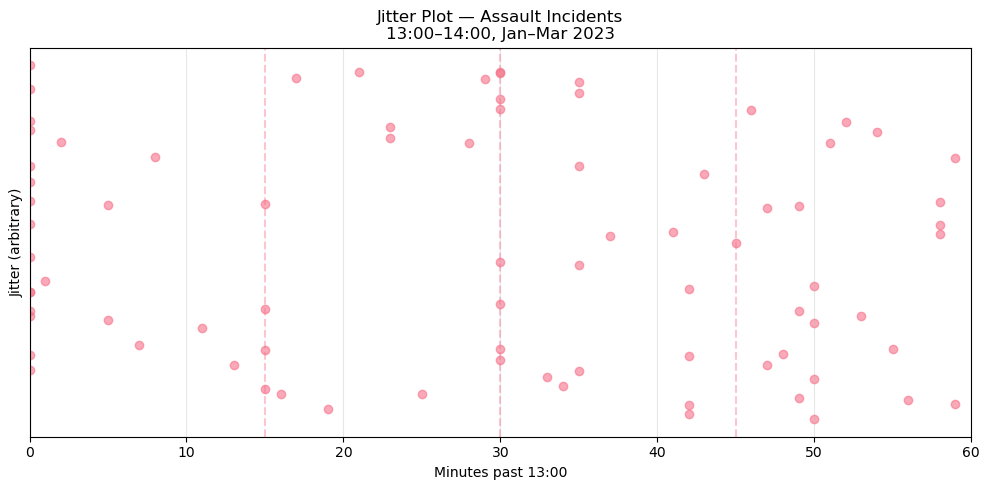

In [193]:

minutes_past_hour = (
    df_hour['DateTime'].dt.minute +
    df_hour['DateTime'].dt.second / 60
)

np.random.seed(42)
jitter = np.random.uniform(-0.4, 0.4, size=len(minutes_past_hour))

plt.figure(figsize=(10,5))
plt.scatter(minutes_past_hour, jitter, alpha=0.6)

plt.xlabel(f"Minutes past {target_hour}:00")
plt.ylabel("Jitter (arbitrary)")
plt.title(f"Jitter Plot — Assault Incidents\n{target_hour}:00–{target_hour+1}:00, Jan–Mar 2023")
plt.xlim(0,60)
plt.yticks([])
plt.grid(axis='x', alpha=0.3)

for m in [0,15,30,45]:
    plt.axvline(m, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [194]:


minute_counts = df_hour['DateTime'].dt.minute.value_counts().sort_index()
second_counts = df_hour['DateTime'].dt.second.value_counts().sort_index()

round_minutes = [0,15,30,45]
round_count = df_hour[df_hour['DateTime'].dt.minute.isin(round_minutes)].shape[0]
total_count = len(df_hour)

print("Clustering at 0,15,30,45 minutes:")
print(f"{round_count}/{total_count} = {round_count/total_count*100:.1f}%")

zero_seconds = df_hour[df_hour['DateTime'].dt.second == 0].shape[0]
print("\nSeconds equal to 0:")
print(f"{zero_seconds}/{total_count} = {zero_seconds/total_count*100:.1f}%")

Clustering at 0,15,30,45 minutes:
28/81 = 34.6%

Seconds equal to 0:
81/81 = 100.0%


### Analysis of Jitter Plot Results

The jitter plot reveals significant **time recording precision issues** in the dataset:

1. **Moderate clustering at round minutes**: 34.6% of incidents (28/81) are recorded at minutes 0, 15, 30, and 45
2. **Complete absence of second-level precision**: 100% of incidents (81/81) have seconds = 0, indicating that ALL times are recorded only to the nearest minute with no sub-minute detail
3. **Systematic rounding behavior**: Over one-third of incidents cluster at convenient quarter-hour intervals, suggesting systematic approximation in time recording

**Statistical Context:**
- **Sample**: 81 assault incidents during 13:00–14:00 in Jan–Mar 2023
- **Time Window**: Selected from 1,394 total assault incidents in the 3-month period
- **Dataset Scale**: Part of 166,595 total assault incidents with valid timestamps

This pattern indicates that incident times are **systematically approximated** rather than precisely recorded, likely due to:
- Officers estimating times after the fact during report writing
- Dispatch systems automatically rounding to convenient intervals
- Administrative convenience prioritizing speed over precision
- Lack of precise timing technology during incident response


## Part B — Probability plot

* Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types.
* What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?

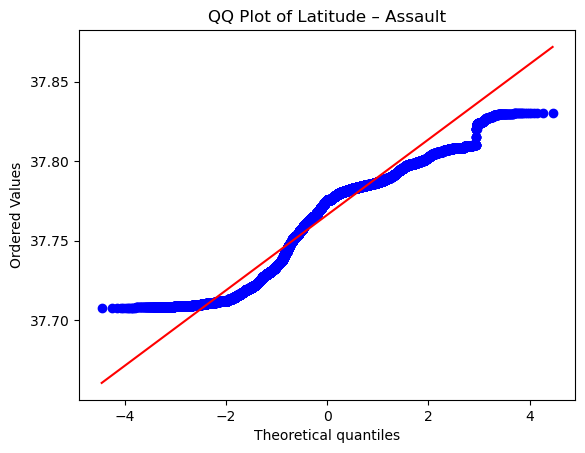

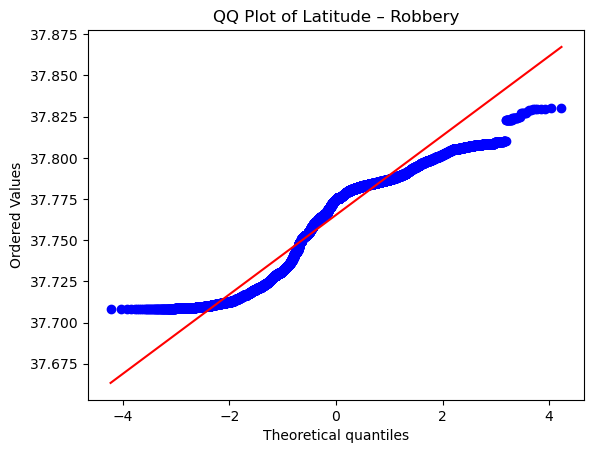

In [195]:
from scipy import stats

# Make sure Latitude is numeric
df_combined['Latitude'] = (
    df_combined['Latitude']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_combined['Latitude'] = pd.to_numeric(
    df_combined['Latitude'],
    errors='coerce'
)

# Filter valid SF latitude range
df_combined = df_combined[
    (df_combined['Latitude'] > 37) &
    (df_combined['Latitude'] < 38)
]

# Standardize Unified Category
df_combined['Unified Category'] = (
    df_combined['Unified Category']
    .astype(str)
    .str.lower()
)

personal_focus_crimes = ['assault', 'robbery', 'burglary']

df_filtered = df_combined[
    df_combined['Unified Category'].isin(personal_focus_crimes)
].copy()

crime_types = ['assault', 'robbery']

for crime in crime_types:
    latitudes = df_filtered[
        df_filtered['Unified Category'] == crime
    ]['Latitude'].dropna()

    plt.figure()
    stats.probplot(latitudes, dist="norm", plot=plt)
    plt.title(f'QQ Plot of Latitude – {crime.capitalize()}')
    plt.show()

## Part B – Probability Plot Interpretation

To analyze the spatial distribution of crime, QQ plots were created for the latitude values of assault and robbery incidents. In both cases, the sample data were compared against a normal distribution, as shown by the straight reference line in the plots.

If the points had fallen exactly on the straight line, this would indicate that the latitude values follow a normal distribution. In practical terms, that would mean crimes are evenly and symmetrically distributed north–south across San Francisco, with no particular clustering or concentration in specific areas.

However, both QQ plots show a clear S shaped deviation from the reference line. The points flatten at the lower and upper tails and curve in the middle. This indicates that the latitude distributions are not normal. Instead of being evenly spread, the crimes are geographically clustered within specific latitude ranges. The flattened tails suggest that relatively few crimes occur at the extreme northern or southern parts of the city, while a large number of incidents are concentrated in central latitude bands.

This deviation from normality reflects the real geography of San Francisco. Crime is not randomly distributed but tends to cluster in particular neighborhoods or high activity areas. The similar patterns observed for assault and robbery also suggest that these two crime types occur in broadly similar parts of the city.

Overall, the QQ plots show that crime in San Francisco is spatially concentrated rather than normally distributed across latitude.


## Part C — Box plots of time-of-day

* For each of your Personal Focus Crimes, extract the time-of-day of every incident.
* Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
* What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
* Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

/var/folders/xc/9wtnldyd2rlc_nnrrrzqqqn40000gn/T/ipykernel_84883/119085756.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


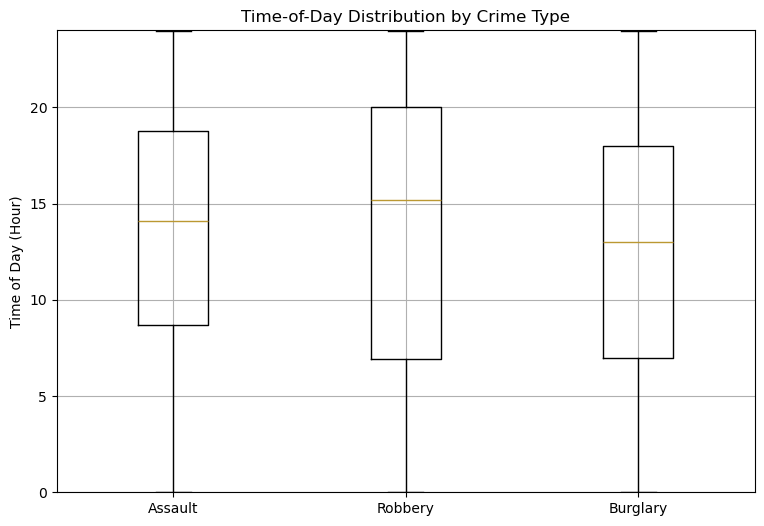

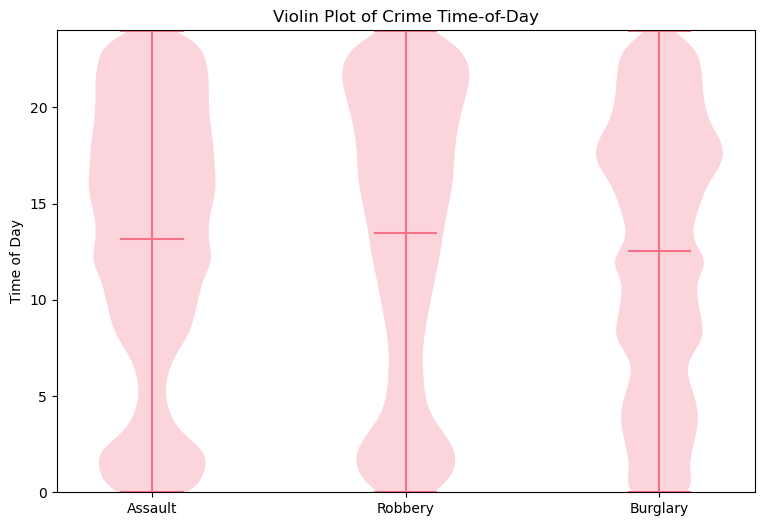

In [196]:
# Extract hour and minute safely using the correct column name 'Time'
df_filtered['Hour'] = df_filtered['Time'].str[:2].astype(int)
df_filtered['Minute'] = df_filtered['Time'].str[3:5].astype(int)

df_filtered['TimeOfDay'] = (
    df_filtered['Hour'] +
    df_filtered['Minute'] / 60
)

import matplotlib.pyplot as plt

personal_focus_crimes = ['assault', 'robbery', 'burglary']

plt.figure(figsize=(9,6))

data = [
    df_filtered[df_filtered['Unified Category'] == crime]['TimeOfDay']
    for crime in personal_focus_crimes
]

plt.boxplot(
    data,
    labels=[c.capitalize() for c in personal_focus_crimes]
)

plt.ylabel('Time of Day (Hour)')
plt.title('Time-of-Day Distribution by Crime Type')
plt.ylim(0, 24)
plt.grid(True)
plt.show()

plt.figure(figsize=(9,6))

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], [c.capitalize() for c in personal_focus_crimes])
plt.ylabel("Time of Day")
plt.ylim(0,24)
plt.title("Violin Plot of Crime Time-of-Day")
plt.show()

## Part C – Time-of-Day Distribution

To analyze when crimes occur during the day, I extracted the hour and minute from the incident time and converted it into a continuous time-of-day variable between 0 and 24 hours. I then created box plots and violin plots to compare assault, robbery, and burglary side by side.

From the box plots, we can see that all three crime types occur throughout the entire day, but there are some differences in their distributions. Assault and robbery both have medians around the early to mid-afternoon, suggesting that many incidents occur during the day and early evening. However, the violin plots show noticeable density during late evening hours as well, especially for assault. This suggests that assaults in particular may also peak late at night.

Burglary appears slightly more concentrated during daytime hours compared to the other two. The median for burglary is somewhat earlier, and the density is stronger during typical business hours. This makes sense, as burglaries often occur when people are away from home during the day.

One limitation of the box plot is how it handles time around midnight. Time-of-day is circular (0:00 comes right after 23:59), but the box plot treats it as linear from 0 to 24. If a crime peaks around midnight (for example at 23:00–02:00), the distribution may appear artificially spread out across both ends of the axis. This can distort the interquartile range and make the distribution look more variable than it really is. In other words, the box plot does not handle the “wrap around” at midnight very well.

The violin plot provides more detail than the box plot because it shows the full density distribution rather than just quartiles and median. For example, it reveals where crime times cluster most heavily and whether there are multiple peaks during the day. This makes it easier to see late-night concentration patterns that are not as clear in the box plot.

Overall, the plots suggest that assault and robbery occur both during the day and late evening, while burglary is somewhat more concentrated during daytime hours.

# Assignment 1.4: Spatial Power Law

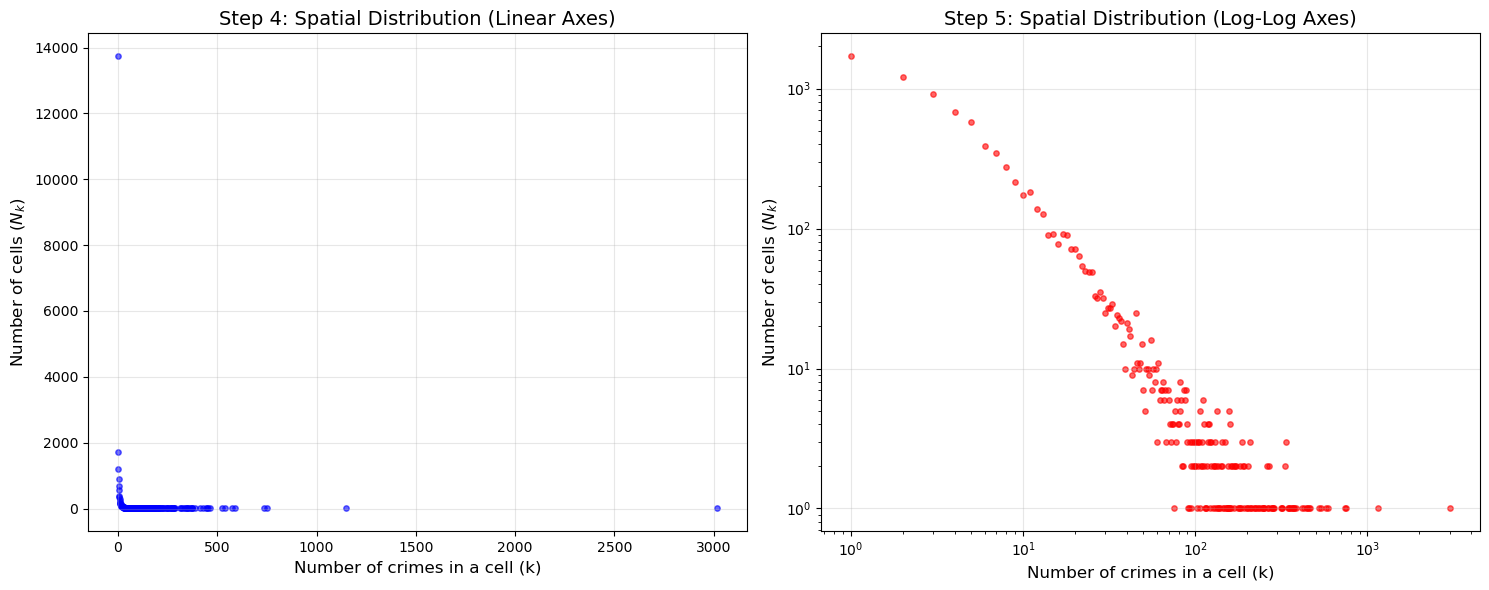

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target_crime = 'Assault'

df_spatial = df_combined[df_combined['Unified Category'].astype(str).str.strip().str.title() == target_crime].copy()

df_spatial['Latitude'] = pd.to_numeric(df_spatial['Latitude'], errors='coerce')
df_spatial['Longitude'] = pd.to_numeric(df_spatial['Longitude'], errors='coerce')
df_spatial = df_spatial.dropna(subset=['Latitude', 'Longitude'])

df_grid = df_spatial[(df_spatial['Latitude'] > 37.7) & (df_spatial['Latitude'] < 37.85) &
                     (df_spatial['Longitude'] > -122.55) & (df_spatial['Longitude'] < -122.35)]


counts, lon_edges, lat_edges = np.histogram2d(
    df_grid['Longitude'], 
    df_grid['Latitude'], 
    bins=150
)


grid_counts = counts.flatten()

k, N_k = np.unique(grid_counts, return_counts=True)

k_valid = k[k > 0]
N_k_valid = N_k[k > 0]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(k, N_k, color='blue', alpha=0.6, s=15)
ax1.set_title('Step 4: Spatial Distribution (Linear Axes)', fontsize=14)
ax1.set_xlabel('Number of crimes in a cell (k)', fontsize=12)
ax1.set_ylabel('Number of cells ($N_k$)', fontsize=12)
ax1.grid(alpha=0.3)

ax2.scatter(k_valid, N_k_valid, color='red', alpha=0.6, s=15)
ax2.set_title('Step 5: Spatial Distribution (Log-Log Axes)', fontsize=14)
ax2.set_xlabel('Number of crimes in a cell (k)', fontsize=12)
ax2.set_ylabel('Number of cells ($N_k$)', fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Step 6: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?**
Yes, it closely follows a power-law distribution. You can tell this from the log-log plot (Step 5) because the data points fall roughly along a decaying straight, diagonal line. In a log-log scale, a straight line mathematical relationship indicates a power-law. This means that a massive number of grid cells have 0 or 1 crimes (the top-left), while a very tiny fraction of cells experience a massive, disproportionate amount of crimes (the bottom-right).

**Step 7: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?**
If crime follows a power law spatially, it means crime is hyper-concentrated. It doesn't happen evenly across a neighborhood; it happens intensely at very specific hotspots (intersections, transit stops, etc.). 
Because of this extreme inequality, calculating the simple "average" or "mean" crime rate for an entire neighborhood is highly misleading. A single extreme hotspot can dramatically drag the average up for an entire neighborhood, concealing the fact that 95% of the blocks in that same neighborhood are perfectly safe. Therefore, the concept of an "average block" is not useful. For policing and city planning, it implies that resources need to be hyper-targeted to the specific micro-geography squares where the power-law dictates almost all the crime is concentrated, rather than evenly patrolling a neighborhood.


# Assignment 1.5: Regression and Correlation

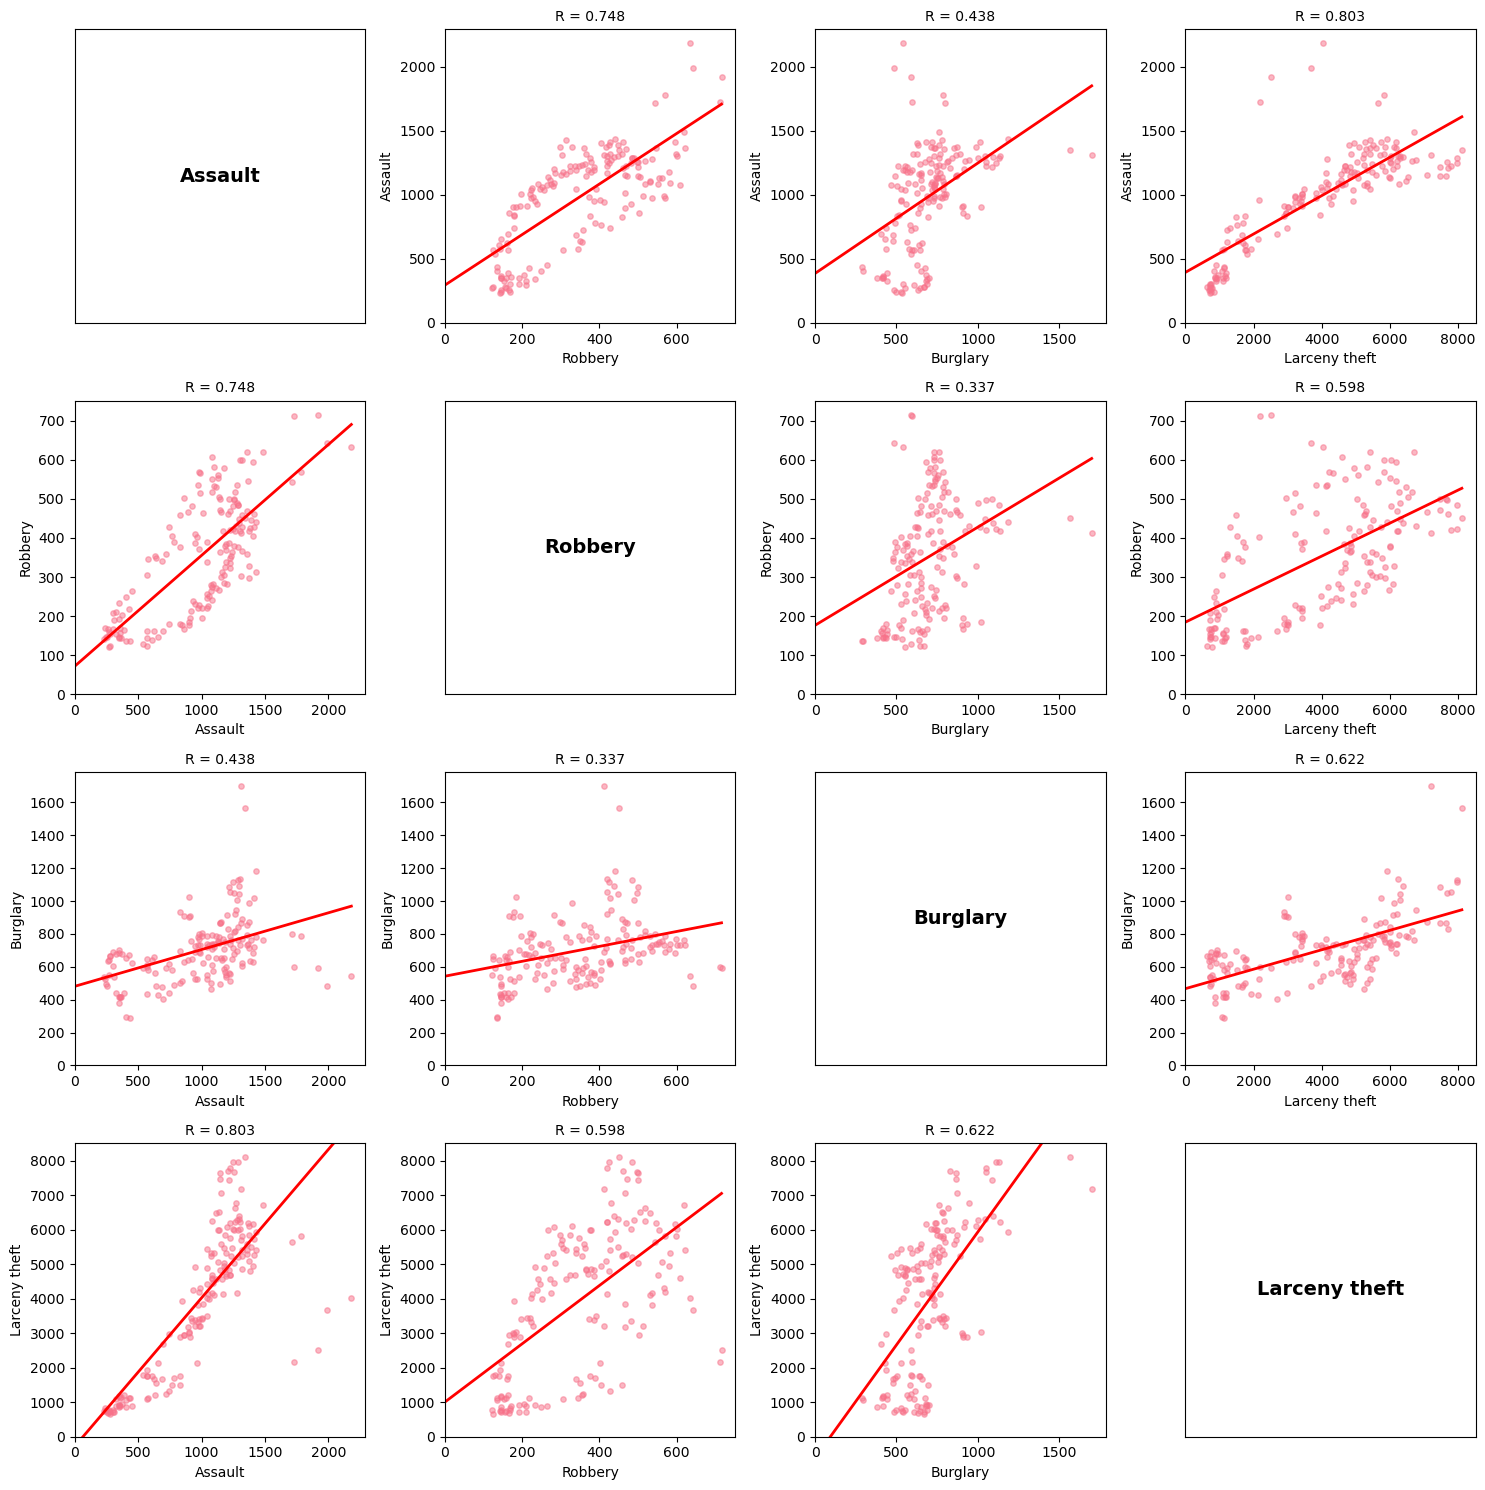

In [198]:
df_filtered = df_combined[df_combined['Unified Category'].astype(str).str.strip().str.title().isin(['Assault', 'Robbery', 'Burglary', 'Larceny Theft'])].copy()

df_filtered['Date'] = pd.to_datetime(df_filtered['Date'], errors='coerce')
df_filtered['DayOfWeek'] = df_filtered['Date'].dt.day_name()

df_filtered['Time'] = df_filtered['Time'].astype(str)
df_filtered['Hour'] = pd.to_numeric(df_filtered['Time'].str.split(':').str[0], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Hour'])
df_filtered['Hour'] = df_filtered['Hour'].astype(int)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

crime_vectors = {}
for crime in ['Assault', 'Robbery', 'Burglary', 'Larceny Theft']:
    crime_df = df_filtered[df_filtered['Unified Category'].astype(str).str.strip().str.title() == crime]
    
    counts = crime_df.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)
    counts = counts.reindex(days_order)
    vector_168 = counts.values.flatten()
    crime_vectors[crime] = vector_168

def linear_regression(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    beta_1 = numerator / denominator
    beta_0 = y_mean - beta_1 * x_mean
    return beta_0, beta_1

def calculate_r(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
    return numerator / denominator

crimes = list(crime_vectors.keys())
n_crimes = len(crimes)

fig, axes = plt.subplots(n_crimes, n_crimes, figsize=(15, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

max_vals = {crime: np.max(crime_vectors[crime]) for crime in crimes}

for i in range(n_crimes):
    for j in range(n_crimes):
        ax = axes[i, j]
        
        if i == j:
            ax.text(0.5, 0.5, crimes[i].capitalize(), ha='center', va='center', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            x_crime = crimes[j]
            y_crime = crimes[i]
            
            x = crime_vectors[x_crime]
            y = crime_vectors[y_crime]
            
            ax.scatter(x, y, alpha=0.5, s=15)
            
            b0, b1 = linear_regression(x, y)
            r = calculate_r(x, y)
            
            x_line = np.array([0, np.max(x)])
            y_line = b0 + b1 * x_line
            ax.plot(x_line, y_line, color='red', linewidth=2)
            
            ax.set_title(f'R = {r:.3f}', fontsize=10)
            ax.set_xlabel(x_crime.capitalize())
            ax.set_ylabel(y_crime.capitalize())
            
            ax.set_xlim(0, max_vals[x_crime] * 1.05)
            ax.set_ylim(0, max_vals[y_crime] * 1.05)

plt.tight_layout()
plt.show()


**Which pair of crimes is most correlated? Which is least correlated? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?**

Looking at the generated regression matrix, the most correlated pair of crimes is **Assault** and **Larceny theft** with an R-value of **0.803**. The least correlated pair is **Robbery** and **Burglary** with an R-value of **0.337**.

This matches intuition because crimes will share a weekly rhythm when they rely on similar opportunity structures. For example, "Assault" and "Larceny theft" often peak closely together during times when public activity and street life are highest (such as weekend afternoons and evenings), increasing both the chance of interpersonal conflict and the availability of targets for theft. In contrast, "Burglary" is largely out of sync with "Robbery" because residential burglaries typically peak during weekday daytime hours when occupants are away at work, whereas robberies rely on intercepting people and thus peak when victims are out on the streets.


# CONTRIBUTION:
* Christoffer Engskov Frost (s224790): Assignment 1.2 & Assigment 1.3 (Part A)
* Michelle Quynh Ngoc Mai (s224771): Assignment 1.1 & Assigment 1.3 (Part B & C)
* Lorenzo Gelao (s253003) : Assignment 1.4 & Assignment 1.5